<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum6/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Data

In [1]:
# import library
import pandas as pd #ok
import matplotlib.pyplot as plt #ok
import seaborn as sns #ok
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC # Import SVC

# import library untuk 3D
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

# Memanggil dataset melalui gdrive
path = "gdrive/MyDrive/MachineLearning/Praktikum/data/week6/"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
df = pd.read_csv(path + "patients.csv")
df.head()

,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-null   object
 4   departure_date  1000 non-null   object
 5   service         1000 non-null   object
 6   satisfaction    1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [5]:
df.describe()

,age,satisfaction
count,1000.000000,1000.000000
mean,45.337000,79.597000
std,25.999912,11.550325
min,0.000000,60.000000
25%,23.000000,70.000000
50%,46.000000,80.000000
75%,68.000000,89.250000
max,89.000000,99.000000


In [6]:
df["service"].unique()

array(['surgery', 'general_medicine', 'emergency', 'ICU'], dtype=object)

In [7]:
df["service"].value_counts()

,count
service,
emergency,263
surgery,254
general_medicine,242
ICU,241


# Pemilihan Fitur

In [8]:
# Kolom 'service' adalah target (Y)
# Kolom 'age' dan 'satisfaction' adalah fitur (X)

# Pemilihan Fitur dan Target
X = df[['age', 'satisfaction']]
y = df['service']

# Split dan Bangun Model SVM

In [9]:
# Memisahkan data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Membuat model SVM dengan kernel linear
model = SVC(kernel='linear')
# Melatih model dengan data latih
model.fit(X_train, y_train)

SVC(kernel='linear')

# Evaluasi Akurasi dan Report Klasifikasi

In [10]:
y_pred = model.predict(X_test)
# Menghitung akurasi model
print(f"Akurasi model: {accuracy_score(y_test, y_pred) *100:.2f}%")
# Menghasilkan laporan klasifikasi
print("\nLaporan Kasifikasi:\n", classification_report(y_test, y_pred, zero_division=1))

Akurasi model: 25.00%

Laporan Kasifikasi:
                   precision    recall  f1-score   support

             ICU       0.00      0.00      0.00        48
       emergency       0.25      0.41      0.31        58
general_medicine       1.00      0.00      0.00        47
         surgery       0.25      0.55      0.35        47

        accuracy                           0.25       200
       macro avg       0.38      0.24      0.17       200
    weighted avg       0.37      0.25      0.17       200



# Visualisasi Hasil Model SVM

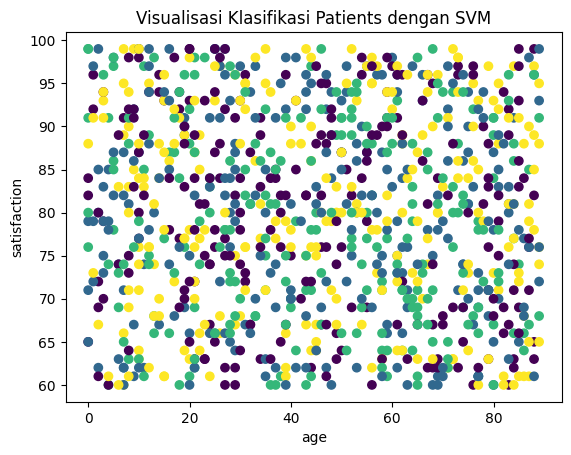

In [11]:
plt.scatter(df['age'], df['satisfaction'], c=df['service'].astype('category').cat.codes)
plt.xlabel('age')
plt.ylabel('satisfaction')
plt.title('Visualisasi Klasifikasi Patients dengan SVM')
plt.show()

# 3D Visualisasi Hasil Model SVM

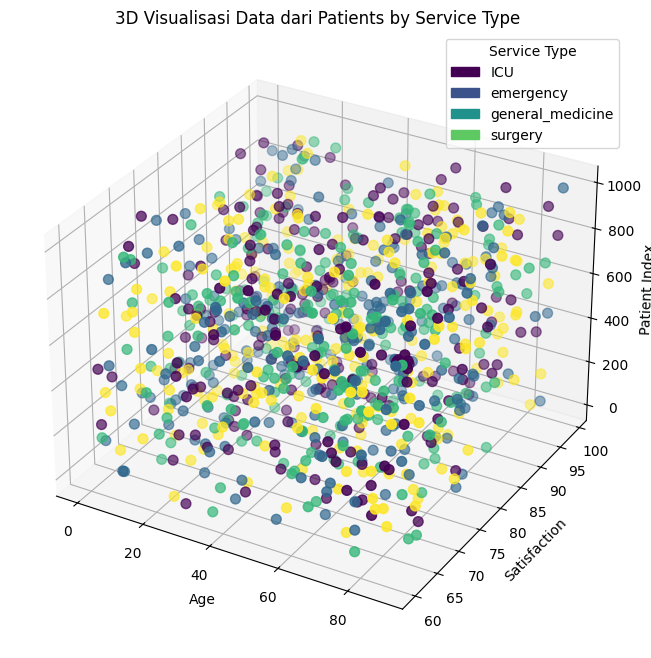

In [17]:
#  Encode label (unduh teks jadi angka)
label_encoder = LabelEncoder()
df['service_encoded'] = label_transform = label_encoder.fit_transform(df['service'])

# Plot 3D hasil klasifikasi
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with age on x, satisfaction on y, and color based on service_encoded
scatter = ax.scatter(df['age'], df['satisfaction'], df.index, c=df['service_encoded'], cmap='viridis', s=50)

ax.set_xlabel('Age')
ax.set_ylabel('Satisfaction')
ax.set_zlabel('Patient Index') # Label for the third dimension
ax.set_title('3D Visualisasi Data dari Patients by Service Type')

# Create a legend
legend_labels = label_encoder.classes_
# Get the colormap using the recommended method
cmap = plt.get_cmap('viridis')
# Import mpatches
import matplotlib.patches as mpatches
# Create a list of legend handles
legend_handles = [mpatches.Patch(color=cmap(i/len(legend_labels)), label=label) for i, label in enumerate(legend_labels)]


ax.legend(handles=legend_handles, title="Service Type")

plt.show()